# EfficientNetB4 -- Figshare 4-Class (224x224, 35 epochs, 100% fine-tuning)
Same data pipeline as before: all Figshare images pooled from its `training images` / `validation images` / `test images` folders, shuffled, and re-split stratified **60% train / 20% validation / 20% test** (`random_state=42`). 4 classes: adenocarcinoma, squamous_cell_carcinoma, large_cell_carcinoma, normal.

**Specifications for this run:**
- Image size: **224x224** (not EfficientNetB4's native 380x380 -- the backbone is fully convolutional with global average pooling, so it accepts this size fine, just not at its originally-tuned resolution)
- Epochs: **35**
- Optimizer: **Adam, learning_rate=5e-4**
- Early stopping: **patience 5** (monitors `val_loss`, restores best weights)
- **100% fine-tuning** -- the entire EfficientNetB4 backbone is trainable from epoch 1 (no frozen-then-fine-tune staging)
- **No data augmentation** and **no class weighting** -- plain EfficientNet preprocessing on all three splits, and every sample contributes equally to the loss

## 0. Explore /kaggle/input

In [1]:
import os

max_depth = 4
base_depth = "/kaggle/input".count(os.sep)
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    depth = dirpath.count(os.sep) - base_depth
    if depth > max_depth:
        dirnames[:] = []
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(dirpath) or dirpath}/  [{len(filenames)} files]  {filenames[:2]}")

input/  [0 files]  []


## 1. Imports

In [2]:
import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

TARGET_CLASSES = ["adenocarcinoma", "squamous_cell_carcinoma", "large_cell_carcinoma", "normal"]
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 5e-4
EARLY_STOP_PATIENCE = 5

## 2. Figshare -- Download

In [3]:
FIGSHARE_DOWNLOAD_URL = "https://ndownloader.figshare.com/files/52627007"
FIGSHARE_ZIP = "/kaggle/working/lung_cancer_dataset.zip"
FIGSHARE_DIR = "/kaggle/working/lung_cancer_dataset"
EXPECTED_SIZE = 138394807

if os.path.exists(FIGSHARE_ZIP) and os.path.getsize(FIGSHARE_ZIP) != EXPECTED_SIZE:
    os.remove(FIGSHARE_ZIP)

if not os.path.exists(FIGSHARE_ZIP):
    print("Downloading Figshare dataset...")
    resp = requests.get(FIGSHARE_DOWNLOAD_URL, stream=True, timeout=120, headers={"User-Agent": "Mozilla/5.0"})
    with open(FIGSHARE_ZIP, "wb") as f:
        for chunk in resp.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    size = os.path.getsize(FIGSHARE_ZIP)
    print("Downloaded size:", size, " Matches expected:", size == EXPECTED_SIZE)

if not os.path.exists(FIGSHARE_DIR):
    print("Extracting...")
    with zipfile.ZipFile(FIGSHARE_ZIP, 'r') as z:
        z.extractall(FIGSHARE_DIR)
    print("Done.")

Downloaded size: 138394807  Matches expected: True
Extracting...
Done.


## 3. Pool ALL images, then stratified 60/20/20 split

In [4]:
FIGSHARE_LABEL_MAP = {
    "adenocarcinoma": "adenocarcinoma",
    "squamous.cell.carcinoma": "squamous_cell_carcinoma",
    "large.cell.carcinoma": "large_cell_carcinoma",
    "normal": "normal",
}

def build_figshare_df_from_folder(folder_name):
    split_dir = None
    for dirpath, dirnames, filenames in os.walk(FIGSHARE_DIR):
        if folder_name in dirnames:
            split_dir = os.path.join(dirpath, folder_name)
            break
    if split_dir is None:
        print(f"!! Could not find '{folder_name}'")
        return pd.DataFrame()
    records = []
    for folder in os.listdir(split_dir):
        folder_path = os.path.join(split_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        raw_prefix = folder.split('_')[0]
        label = FIGSHARE_LABEL_MAP.get(raw_prefix)
        if label is None:
            continue
        for fname in os.listdir(folder_path):
            records.append({"filepath": os.path.join(folder_path, fname), "label": label})
    return pd.DataFrame(records)

_train_part = build_figshare_df_from_folder("training images")
_val_part   = build_figshare_df_from_folder("validation images")
_test_part  = build_figshare_df_from_folder("test images")

full_pool = pd.concat([_train_part, _val_part, _test_part], ignore_index=True)
full_pool = full_pool.sample(frac=1.0, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    full_pool, train_size=0.60, stratify=full_pool["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df), " Val size:", len(val_df), " Test size:", len(test_df))
print("\nTrain class balance:\n", train_df["label"].value_counts())
print("\nVal class balance:\n", val_df["label"].value_counts())
print("\nTest class balance:\n", test_df["label"].value_counts())

Train size: 600  Val size: 200  Test size: 200

Train class balance:
 label
adenocarcinoma             203
squamous_cell_carcinoma    156
normal                     129
large_cell_carcinoma       112
Name: count, dtype: int64

Val class balance:
 label
adenocarcinoma             67
squamous_cell_carcinoma    52
normal                     43
large_cell_carcinoma       38
Name: count, dtype: int64

Test class balance:
 label
adenocarcinoma             68
squamous_cell_carcinoma    52
normal                     43
large_cell_carcinoma       37
Name: count, dtype: int64


## 4. Data generators -- no augmentation, plain EfficientNet preprocessing for all splits

In [5]:
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
val_gen = datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
test_gen = datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
print("class_indices:", train_gen.class_indices)

Found 600 validated image filenames belonging to 4 classes.
Found 200 validated image filenames belonging to 4 classes.
Found 200 validated image filenames belonging to 4 classes.
class_indices: {'adenocarcinoma': 0, 'squamous_cell_carcinoma': 1, 'large_cell_carcinoma': 2, 'normal': 3}


## 5. Model -- EfficientNetB4, 100% trainable from the start
`pooling="avg"` handles pooling inside the base model. Single `Dense(4, softmax)` on top. `base_model.trainable = True` -- the whole backbone (not just the last few layers) is fine-tuned from epoch 1, per spec.

In [6]:
base_model = EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling="avg"
)
base_model.trainable = True  # 100% fine-tuning -- entire backbone trainable from epoch 1

output_layer = Dense(NUM_CLASSES, activation="softmax")(base_model.output)
model = Model(inputs=base_model.input, outputs=output_layer)
model.summary()

model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy"]
)

I0000 00:00:1789928571.377365      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789928571.380562      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 17,680,995 (67.45 MB)

 Trainable params: 17,555,788 (66.97 MB)

 Non-trainable params: 125,207 (489.09 KB)

## 6. FLOPs -- cost of fine-tuning (image-wise and batch-wise)
Computes actual FLOPs (floating point operations) for this exact model at 224x224, using TensorFlow's graph profiler -- not a lookup-table estimate, but a real trace of `model`'s ops.

**Forward pass** is measured directly. **Training FLOPs (this fine-tuning run)** are then estimated as forward + backward, using the standard `~3x forward FLOPs` approximation (1x forward, ~2x backward -- one pass to get gradients w.r.t. activations, one w.r.t. weights). This 3x multiplier is the correct one *here specifically* because `base_model.trainable = True` -- the entire backbone gets gradients, not just a small head, so there's no shortcut savings from a frozen backbone.

In [7]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(keras_model, batch_size=1):
    """Forward-pass FLOPs for `keras_model` at the given batch size, via TF's graph profiler."""
    input_shape = [batch_size] + list(keras_model.input.shape[1:])
    concrete_func = tf.function(lambda x: keras_model(x)).get_concrete_function(
        tf.TensorSpec(input_shape, keras_model.input.dtype)
    )
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd="op", options=opts)
    return flops.total_float_ops

TRAINING_FLOPS_MULTIPLIER = 3  # forward (1x) + backward (~2x), valid since 100% of the backbone is trainable

# --- Forward pass ---
flops_per_image_fwd = get_flops(model, batch_size=1)
flops_per_batch_fwd = get_flops(model, batch_size=BATCH_SIZE)

# --- Fine-tuning (forward + backward) ---
flops_per_image_train = flops_per_image_fwd * TRAINING_FLOPS_MULTIPLIER
flops_per_batch_train = flops_per_batch_fwd * TRAINING_FLOPS_MULTIPLIER

steps_per_epoch = len(train_df) // BATCH_SIZE
flops_per_epoch_train = flops_per_batch_train * steps_per_epoch
flops_full_run_train = flops_per_epoch_train * EPOCHS  # upper bound -- ignores early stopping cutting epochs short

print("=== Forward pass ===")
print(f"Per image:  {flops_per_image_fwd:,} FLOPs  (~{flops_per_image_fwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_fwd:,} FLOPs  (~{flops_per_batch_fwd/1e9:.3f} GFLOPs)")

print("\n=== Fine-tuning (forward + backward, ~3x forward) ===")
print(f"Per image:  {flops_per_image_train:,} FLOPs  (~{flops_per_image_train/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_train:,} FLOPs  (~{flops_per_batch_train/1e9:.3f} GFLOPs)")
print(f"\nSteps per epoch: {steps_per_epoch}  (train set size {len(train_df)} / batch size {BATCH_SIZE})")
print(f"Per epoch:  {flops_per_epoch_train:,} FLOPs  (~{flops_per_epoch_train/1e12:.3f} TFLOPs)")
print(f"Full {EPOCHS}-epoch run (upper bound, no early stopping):  {flops_full_run_train:,} FLOPs  (~{flops_full_run_train/1e15:.3f} PFLOPs)")

I0000 00:00:1789928579.104593      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789928579.104793      58 single_machine.cc:376] Starting new session
I0000 00:00:1789928579.119310      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789928579.120881      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation ker

I0000 00:00:1789928587.463380      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789928587.463627      58 single_machine.cc:376] Starting new session
I0000 00:00:1789928587.478085      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789928587.479672      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

## 7. Callbacks

In [8]:
callbacks = [
    ModelCheckpoint("best_effnetb4_figshare_224.keras", monitor="val_accuracy", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True, verbose=1),
]

## 8. Fine-tune (100% -- entire backbone trainable)

In [9]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/35


2026-09-20 18:24:43.214992: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:24:43.348823: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:24:43.585559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:24:43.725075: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:24:43.977962: E external/local_xla/xla/stream_

28/38 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.5385 - loss: 0.9949

2026-09-20 18:26:03.310331: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:26:03.443868: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:26:03.673321: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:26:03.809141: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:26:04.047630: E external/local_xla/xla/stream_

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5761 - loss: 0.9351
Epoch 1: val_accuracy improved from None to 0.67000, saving model to best_effnetb4_figshare_224.keras

Epoch 1: finished saving model to best_effnetb4_figshare_224.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 249s 3s/step - accuracy: 0.7000 - loss: 0.7231 - val_accuracy: 0.6700 - val_loss: 0.8610
Epoch 2/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9234 - loss: 0.2270
Epoch 2: val_accuracy improved from 0.67000 to 0.73000, saving model to best_effnetb4_figshare_224.keras

Epoch 2: finished saving model to best_effnetb4_figshare_224.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - accuracy: 0.9233 - loss: 0.2358 - val_accuracy: 0.7300 - val_loss: 0.7268
Epoch 3/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9519 - loss: 0.1603
Epoch 3: val_accuracy improved from 0.73000 to 0.92000, saving model to best_effnetb4_figshare_224.keras

Epoch 3: finished saving model to best_effnetb4_figshare_224.keras
38/38 

## 9. Plot train/val loss + accuracy

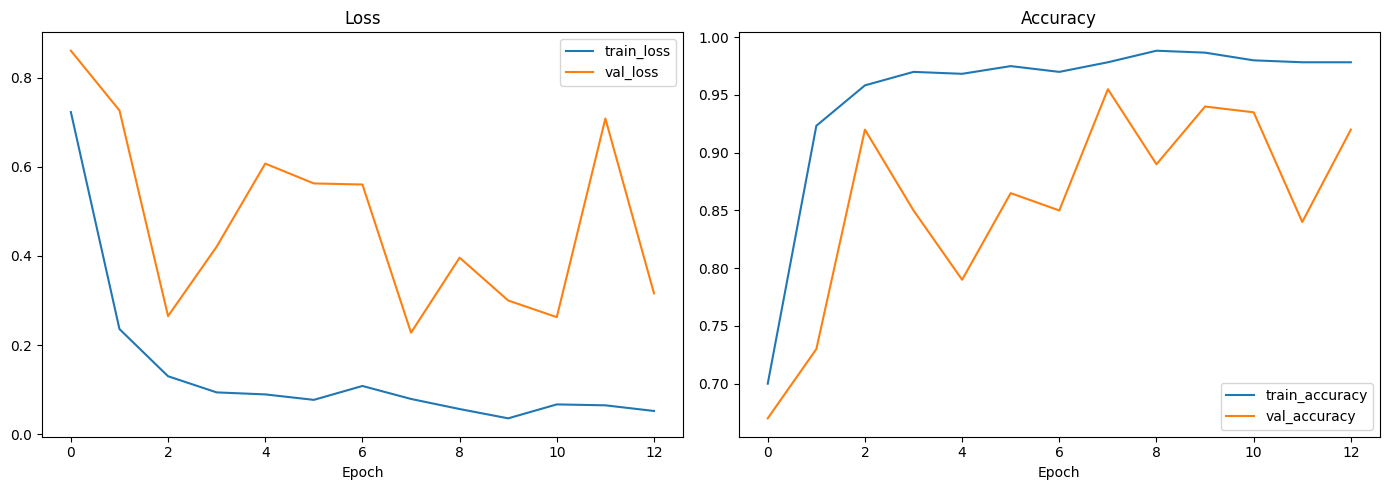

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train_accuracy")
axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_effnetb4_figshare_224.png", dpi=150)
plt.show()

## 10. Final evaluation on TEST set

13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 596ms/step - accuracy: 0.9500 - loss: 0.2759
Test loss: 0.2759  Test accuracy: 0.9500

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma     0.9306    0.9853    0.9571        68
squamous_cell_carcinoma     0.9091    0.9615    0.9346        52
   large_cell_carcinoma     1.0000    0.8649    0.9275        37
                 normal     1.0000    0.9535    0.9762        43

               accuracy                         0.9500       200
              macro avg     0.9599    0.9413    0.9489       200
           weighted avg     0.9528    0.9500    0.9499       200

Test macro F1: 0.9489

Prediction distribution:
adenocarcinoma             72
squamous_cell_carcinoma    55
normal                     41
large_cell_carcinoma       32
Name: count, dtype: int64


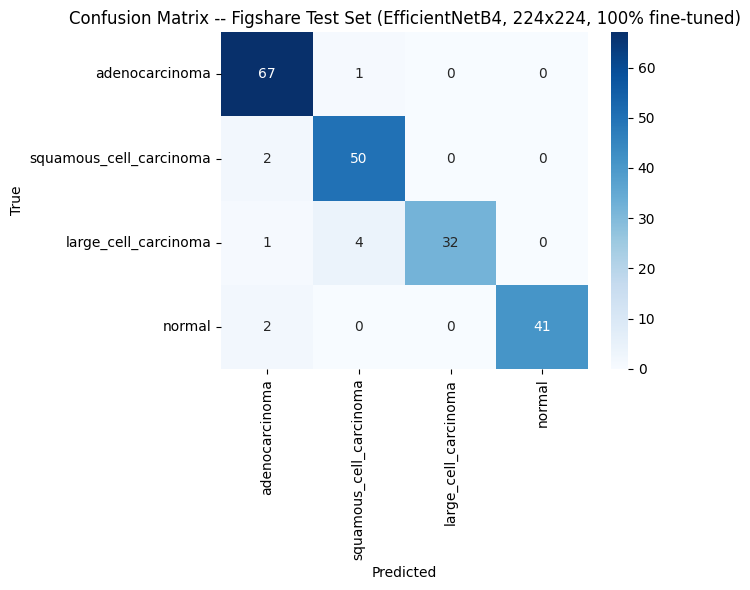


EfficientNetB4 (Figshare, 224x224) test accuracy: 95.00%


In [11]:
best_model = tf.keras.models.load_model("best_effnetb4_figshare_224.keras")

test_gen.reset()
test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

test_gen.reset()
y_pred_probs = best_model.predict(test_gen, verbose=0)
y_pred_idx = np.argmax(y_pred_probs, axis=1)
y_true_idx = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true_idx, y_pred_idx, target_names=TARGET_CLASSES, digits=4))

test_macro_f1 = f1_score(y_true_idx, y_pred_idx, average="macro")
print(f"Test macro F1: {test_macro_f1:.4f}")

print("\nPrediction distribution:")
print(pd.Series(y_pred_idx).map({i: c for i, c in enumerate(TARGET_CLASSES)}).value_counts())

cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix -- Figshare Test Set (EfficientNetB4, 224x224, 100% fine-tuned)")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_effnetb4_figshare_224.png", dpi=150)
plt.show()

print(f"\nEfficientNetB4 (Figshare, 224x224) test accuracy: {test_acc*100:.2f}%")

In [12]:
#correct flop

from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(keras_model, batch_size=1):
    """Forward-pass FLOPs for `keras_model` at the given batch size, via TF's graph profiler."""
    input_shape = [batch_size] + list(keras_model.input.shape[1:])
    concrete_func = tf.function(lambda x: keras_model(x)).get_concrete_function(
        tf.TensorSpec(input_shape, keras_model.input.dtype)
    )
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd="op", options=opts)
    return flops.total_float_ops

# --- Trainable-vs-frozen split, read directly off the model (handles "100% fine-tuning" automatically) ---
trainable_param_count = sum(int(tf.size(w)) for w in model.trainable_weights)
total_param_count = sum(int(tf.size(w)) for w in model.weights)
trainable_fraction = trainable_param_count / total_param_count   # 1.0 here, since base_model.trainable = True

BACKWARD_MULTIPLIER = 2 * trainable_fraction   # backward pass cost, scaled by how much is actually trainable
TOTAL_MULTIPLIER = 1 + BACKWARD_MULTIPLIER      # forward (always 1x) + backward

print(f"Trainable params: {trainable_param_count:,} / {total_param_count:,}  (trainable_fraction={trainable_fraction:.4f})")

# --- FORWARD pass FLOPs ---
flops_per_image_fwd = get_flops(model, batch_size=1)
flops_per_batch_fwd = get_flops(model, batch_size=BATCH_SIZE)

# --- BACKWARD pass FLOPs (derived, not separately traced -- backward isn't directly profilable the same way) ---
flops_per_image_bwd = flops_per_image_fwd * BACKWARD_MULTIPLIER
flops_per_batch_bwd = flops_per_batch_fwd * BACKWARD_MULTIPLIER

# --- TOTAL training FLOPs (forward + backward) ---
flops_per_image_total = flops_per_image_fwd * TOTAL_MULTIPLIER
flops_per_batch_total = flops_per_batch_fwd * TOTAL_MULTIPLIER

steps_per_epoch = len(train_df) // BATCH_SIZE
flops_per_epoch_total = flops_per_batch_total * steps_per_epoch
flops_full_run_total = flops_per_epoch_total * EPOCHS  # upper bound -- ignores early stopping

print("\n=== FORWARD ===")
print(f"Per image:  {flops_per_image_fwd:,}  (~{flops_per_image_fwd/1e9:.3f} GFLOPs)")
print(f"Per batch:  {flops_per_batch_fwd:,}  (~{flops_per_batch_fwd/1e9:.3f} GFLOPs)")

print("\n=== BACKWARD ===")
print(f"Per image:  {flops_per_image_bwd:,.0f}  (~{flops_per_image_bwd/1e9:.3f} GFLOPs)")
print(f"Per batch:  {flops_per_batch_bwd:,.0f}  (~{flops_per_batch_bwd/1e9:.3f} GFLOPs)")

print("\n=== TOTAL (forward + backward) ===")
print(f"Per image:  {flops_per_image_total:,.0f}  (~{flops_per_image_total/1e9:.3f} GFLOPs)")
print(f"Per batch:  {flops_per_batch_total:,.0f}  (~{flops_per_batch_total/1e9:.3f} GFLOPs)")
print(f"Per epoch:  {flops_per_epoch_total:,.0f}  (~{flops_per_epoch_total/1e12:.3f} TFLOPs)  [{steps_per_epoch} steps/epoch]")
print(f"Full {EPOCHS}-epoch run (upper bound, no early stopping):  {flops_full_run_total:,.0f}  (~{flops_full_run_total/1e15:.3f} PFLOPs)")

Trainable params: 17,555,788 / 17,680,995  (trainable_fraction=0.9929)


I0000 00:00:1789929117.142433      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789929117.142621      58 single_machine.cc:376] Starting new session
I0000 00:00:1789929117.157680      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789929117.159298      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

I0000 00:00:1789929126.361752      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789929126.361965      58 single_machine.cc:376] Starting new session
I0000 00:00:1789929126.377039      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789929126.378696      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th